In [19]:
import numpy as np
import matplotlib.pyplot as plt
import math,copy

In [5]:
def sigmoid(z):
    return 1/(1+np.exp(-z))
    

In [6]:
def compute_cost_logistic(X,y,w,b):

    m=X.shape[0]

    cost=0
    for i in range(m):
        z_i=X[i]@w+b
        f_wb_i=sigmoid(z_i)
        cost+=-y[i]*np.log(f_wb_i)-(1-y[i])*np.log(1-f_wb_i)
    cost=cost/m


    return cost
    
        

In [9]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])                                           #(m,)

In [11]:
def plot_data(X, y):
    # Separate the classes
    X_pos = X[y == 1]
    X_neg = X[y == 0]

    # Positive examples
    plt.scatter(
        X_pos[:, 0], X_pos[:, 1],
        marker='x',
        s=180,
        color='red',
        linewidths=4,
        label='y=1'
    )

    # Negative examples
    plt.scatter(
        X_neg[:, 0], X_neg[:, 1],
        marker='o',
        s=180,
        facecolors='none',
        edgecolors='dodgerblue',
        linewidths=3,
        label='y=0'
    )

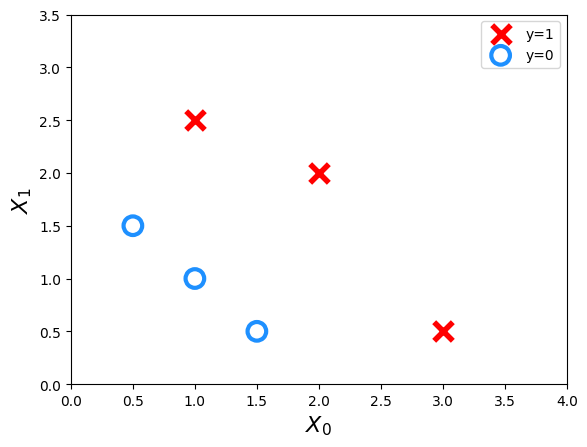

In [12]:
plot_data(X_train, y_train)
plt.xlabel(r'$X_0$', fontsize=16)
plt.ylabel(r'$X_1$', fontsize=16)

# Limits
plt.xlim(0,4)
plt.ylim(0,3.5)

# Legend
plt.legend()
plt.show()

In [28]:
def compute_gradients(X,y,w,b):
    m,n=X.shape

    dj_dw=np.zeros(n)
    dj_db=0

    for i in range(m):
        f_wb_i=sigmoid(np.dot(w,X[i])+b)
        loss=f_wb_i-y[i]
        for j in range(n):
            dj_dw[j]=dj_dw[j]+loss*X[i,j]
        dj_db=dj_db+loss

    dj_dw=dj_dw/m
    dj_db=dj_db/m

    return dj_db,dj_dw

In [29]:
def gradient_descent(X,y,w_in,b_in,max_iters,alpha):
    J_history=[]
    w=copy.deepcopy(w_in)
    b=b_in
    for i in range(max_iters):
        dj_db,dj_dw=compute_gradients(X,y,w,b)

        w=w-alpha*dj_dw
        b=b-alpha*dj_db

        J_history.append(compute_cost_logistic(X,y,w,b))

        if i%math.ceil(max_iters/10)==0:
            print(f'Iteration{i:4d} cost{J_history[-1]}')

    return w,b,J_history

In [32]:
w_in=np.zeros(X_train.shape[1])
b_in=0
max_iters=10000
alpha=0.1
w_out,b_out,J_history=gradient_descent(X_train,y_train,w_in,b_in,max_iters,alpha)

Iteration   0 cost0.684610468560574
Iteration1000 cost0.1590977666870456
Iteration2000 cost0.08460064176930081
Iteration3000 cost0.05705327279402531
Iteration4000 cost0.042907594216820076
Iteration5000 cost0.034338477298845684
Iteration6000 cost0.028603798022120097
Iteration7000 cost0.024501569608793
Iteration8000 cost0.02142370332569295
Iteration9000 cost0.019030137124109114


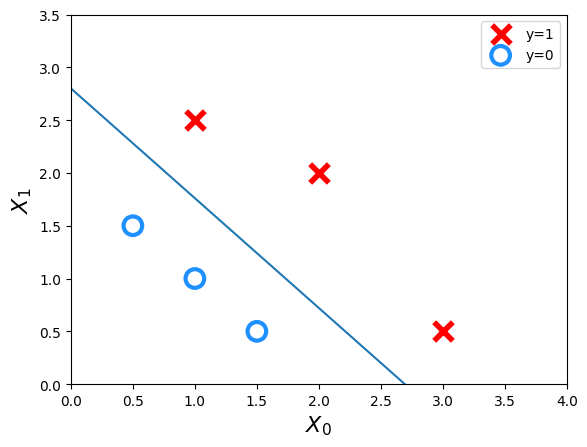

In [35]:
plot_data(X_train, y_train)
plt.xlabel(r'$X_0$', fontsize=16)
plt.ylabel(r'$X_1$', fontsize=16)

# Limits
plt.xlim(0,4)
plt.ylim(0,3.5)

# Legend
plt.legend()

#decision boundaries

x0=-b_out/w_out[0]
x1=-b_out/w_out[1]
plt.plot([0,x0],[x1,0])




plt.show()